In [1]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


/tmp/ipykernel_1219/3287132413.py:23: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv('train.csv')


       ID Customer_ID     Month           Name   Age          SSN Occupation  \
0  0x1602   CUS_0xd40   January  Aaron Maashoh    23  821-00-0265  Scientist   
1  0x1603   CUS_0xd40  February  Aaron Maashoh    23  821-00-0265  Scientist   
2  0x1604   CUS_0xd40     March  Aaron Maashoh  -500  821-00-0265  Scientist   
3  0x1605   CUS_0xd40     April  Aaron Maashoh    23  821-00-0265  Scientist   
4  0x1606   CUS_0xd40       May  Aaron Maashoh    23  821-00-0265  Scientist   

  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  ...  Credit_Mix  \
0      19114.12            1824.843333                  3  ...           _   
1      19114.12                    NaN                  3  ...        Good   
2      19114.12                    NaN                  3  ...        Good   
3      19114.12                    NaN                  3  ...        Good   
4      19114.12            1824.843333                  3  ...        Good   

   Outstanding_Debt Credit_Utilization_Ratio     C

/tmp/ipykernel_1219/3287132413.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df = train_df.fillna(method='ffill')
/tmp/ipykernel_1219/3287132413.py:43: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  submission_test_df = submission_test_df.fillna(method='ffill') # Apply to submission_test_df
/tmp/ipykernel_1219/3287132413.py:59: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df = train_df.fillna(method='ffill')
/tmp/ipykernel_1219/3287132413.py:60: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  submission_test_df = submission_test_df.fillna(method='ffill') # Apply to submission_test_df


Reduced features: 21

===== Logistic Regression ====
Accuracy: 0.6003
              precision    recall  f1-score   support

           0       0.51      0.31      0.39      3527
           1       0.64      0.42      0.50      5874
           2       0.60      0.80      0.69     10599

    accuracy                           0.60     20000
   macro avg       0.58      0.51      0.53     20000
weighted avg       0.60      0.60      0.58     20000



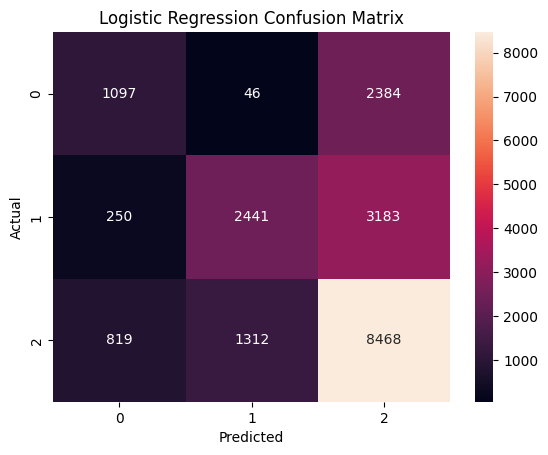


===== KNN ====
Accuracy: 0.6051
              precision    recall  f1-score   support

           0       0.46      0.52      0.49      3527
           1       0.60      0.52      0.56      5874
           2       0.66      0.68      0.67     10599

    accuracy                           0.61     20000
   macro avg       0.57      0.57      0.57     20000
weighted avg       0.61      0.61      0.60     20000



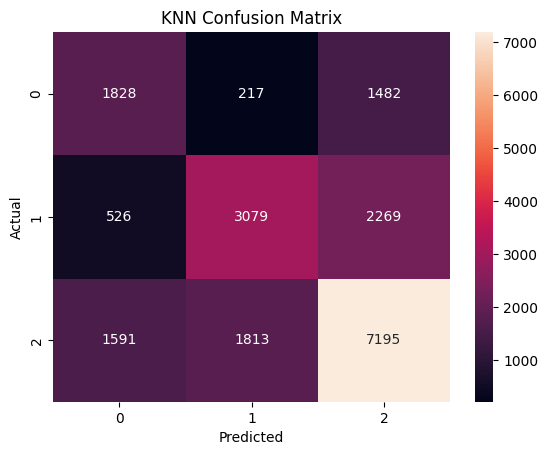


===== Decision Tree ====
Accuracy: 0.54615
              precision    recall  f1-score   support

           0       0.40      0.41      0.41      3527
           1       0.50      0.51      0.50      5874
           2       0.62      0.61      0.62     10599

    accuracy                           0.55     20000
   macro avg       0.51      0.51      0.51     20000
weighted avg       0.55      0.55      0.55     20000



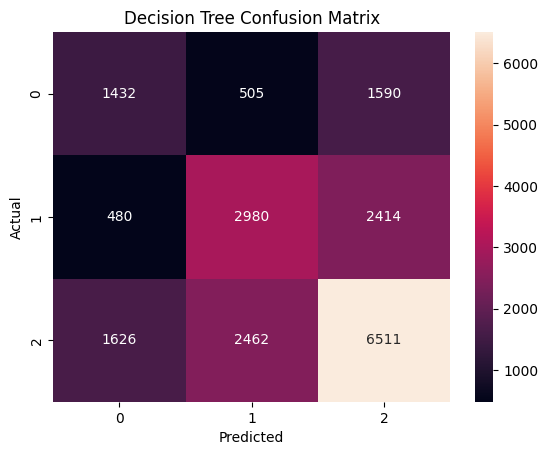


===== Random Forest ====
Accuracy: 0.6483
              precision    recall  f1-score   support

           0       0.54      0.48      0.51      3527
           1       0.70      0.52      0.59      5874
           2       0.66      0.78      0.71     10599

    accuracy                           0.65     20000
   macro avg       0.63      0.59      0.60     20000
weighted avg       0.65      0.65      0.64     20000



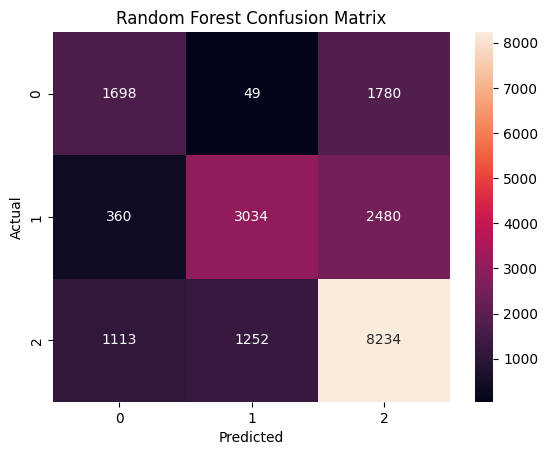


===== SVM ====
Accuracy: 0.6398
              precision    recall  f1-score   support

           0       0.51      0.58      0.54      3527
           1       0.72      0.44      0.55      5874
           2       0.66      0.77      0.71     10599

    accuracy                           0.64     20000
   macro avg       0.63      0.60      0.60     20000
weighted avg       0.65      0.64      0.63     20000



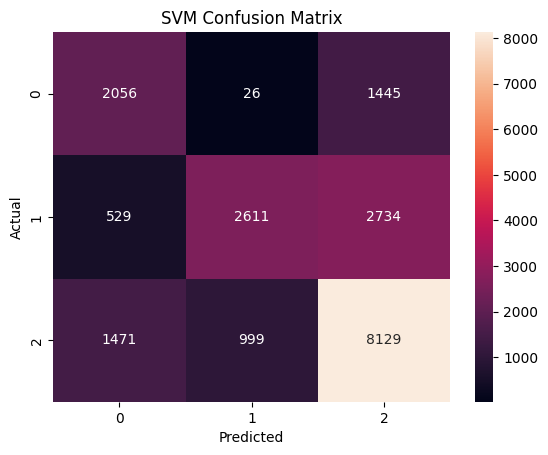


Final Model Accuracies:
Logistic Regression: 0.6003
KNN: 0.6051
Decision Tree: 0.54615
Random Forest: 0.6483
SVM: 0.6398


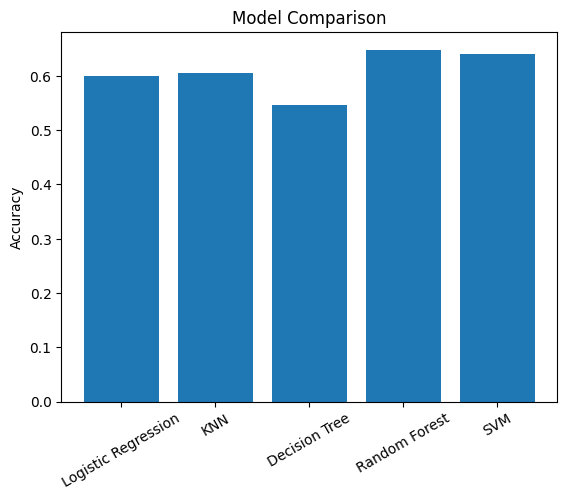

In [5]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split # Added this line

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# =========================
# 2. LOAD DATASET
# =========================
train_df = pd.read_csv('train.csv')
submission_test_df = pd.read_csv('test.csv') # Renamed to avoid confusion with X_test/y_test for evaluation

print(train_df.head())
print(train_df.info())

# =========================
# 3. PREPROCESSING
# =========================

# Drop unnecessary columns (if exist)
drop_cols = ['ID', 'Customer_ID', 'Name']
for col in drop_cols:
    if col in train_df.columns:
        train_df.drop(col, axis=1, inplace=True)
    if col in submission_test_df.columns: # Apply to submission_test_df
        submission_test_df.drop(col, axis=1, inplace=True)

# Handle missing values initially (for existing NaNs)
train_df = train_df.fillna(method='ffill')
submission_test_df = submission_test_df.fillna(method='ffill') # Apply to submission_test_df

# Identify columns that should be numeric but might be object type due to mixed data
numeric_object_cols = [
    'Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
    'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly',
    'Monthly_Balance'
]

for col in numeric_object_cols:
    if col in train_df.columns:
        train_df[col] = pd.to_numeric(train_df[col], errors='coerce')
    if col in submission_test_df.columns: # Apply to submission_test_df
        submission_test_df[col] = pd.to_numeric(submission_test_df[col], errors='coerce')

# Re-apply fillna for NaNs created by pd.to_numeric
train_df = train_df.fillna(method='ffill')
submission_test_df = submission_test_df.fillna(method='ffill') # Apply to submission_test_df

# Encode categorical columns
le = LabelEncoder()
for col in train_df.select_dtypes(include='object').columns:
    # Ensure all values are strings before encoding to prevent TypeError
    train_df[col] = train_df[col].astype(str)
    train_df[col] = le.fit_transform(train_df[col])

for col in submission_test_df.select_dtypes(include='object').columns: # Apply to submission_test_df
    # Ensure all values are strings before encoding to prevent TypeError
    submission_test_df[col] = submission_test_df[col].astype(str)
    submission_test_df[col] = le.fit_transform(submission_test_df[col])

# =========================
# 4. SPLIT FEATURES & LABEL
# =========================
target_column = 'Credit_Score'

# Split train_df into training and validation sets for evaluation
X = train_df.drop(target_column, axis=1)
y = train_df[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Prepare submission_test_df for making final predictions (without a target column)
X_submission = submission_test_df.copy() # This will be used for final prediction if needed

# =========================
# 5. FEATURE SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_submission = scaler.transform(X_submission) # Scale the submission data too

# =========================
# 6. PCA (FEATURE REDUCTION)
# =========================
pca = PCA(n_components=0.95)  # keep 95% variance
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
X_submission = pca.transform(X_submission) # Apply PCA to submission data

print("Reduced features:", X_train.shape[1])

# =========================
# 7. MODELS (5 CLASSIFIERS)
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC()
}

results = {}

# =========================
# 8. TRAIN & EVALUATE
# =========================
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test) # X_test is now the validation set

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n===== {name} ====")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    plt.figure()
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# =========================
# 9. RESULT COMPARISON
# =========================
print("\nFinal Model Accuracies:")
for model, acc in results.items():
    print(f"{model}: {acc}")

# Bar graph
plt.figure()
plt.bar(results.keys(), results.values())
plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

# If predictions on the actual submission_test_df are needed:
# final_predictions = {}
# for name, model in models.items():
#     final_predictions[name] = model.predict(X_submission)
#     print(f"Predictions for {name} on submission data: {final_predictions[name][:5]}")